In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

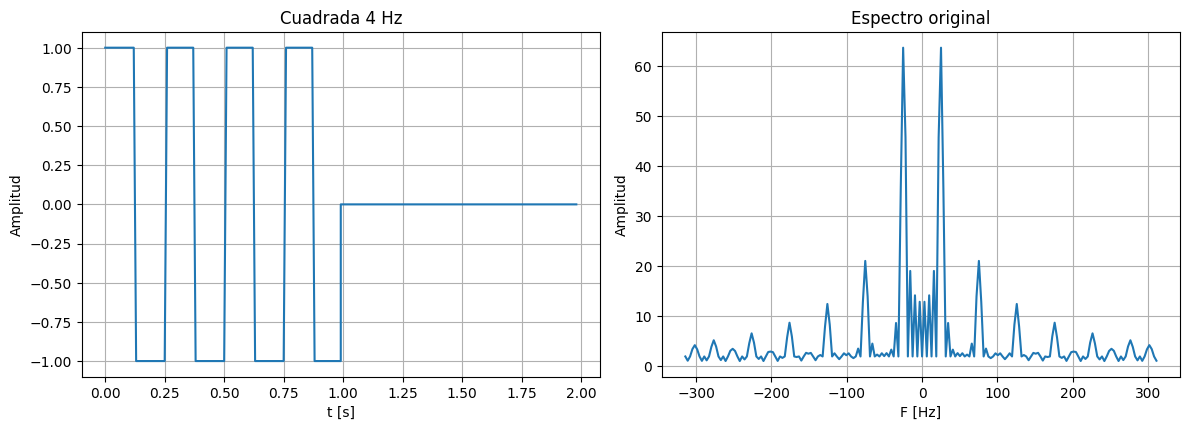

In [38]:
def generar_senoidal(N, frecs, frecM, std=None):
    # N = n° segundos
    Tm = 1/frecM

    dom = np.arange(0, N, Tm)

    senoidal_final = np.zeros_like(dom)
    for f in range(len(frecs)):
        senoidal = np.sin(dom * 2 * np.pi * frecs[f])
        if std is not None:
            senoidal *= np.random.rand() * std

        senoidal_final += senoidal
    
    
    return dom, senoidal_final

frecM = 100
duracion = 1
dom, seno_comb = generar_senoidal(duracion, [4], frecM)

seno_comb = ((seno_comb >= 0).astype(float))*2-1
seno_comb = np.hstack((seno_comb, np.zeros((len(seno_comb)))))
dom = np.hstack((dom, np.max(dom) + dom))

fft_seno_comb = np.fft.fft(seno_comb, len(seno_comb))
norm_seno_comb = np.abs(fft_seno_comb)

fft_frecs = 2 * np.pi * np.fft.fftfreq(len(seno_comb), 1/frecM)
shift_frecs = np.fft.fftshift(fft_frecs)
shift_seno_comb = np.fft.fftshift(norm_seno_comb)

plt.figure(figsize=(12,8))
plt.subplot(2,2,1)
plt.title("Cuadrada 4 Hz")
plt.plot(dom, seno_comb)
plt.xlabel('t [s]')
plt.ylabel('Amplitud')
plt.grid(True)

plt.subplot(2,2,2)
plt.title("Espectro original")
plt.plot(shift_frecs, shift_seno_comb)
plt.xlabel('F [Hz]')
plt.ylabel('Amplitud')
plt.grid(True)

plt.tight_layout()
plt.show()

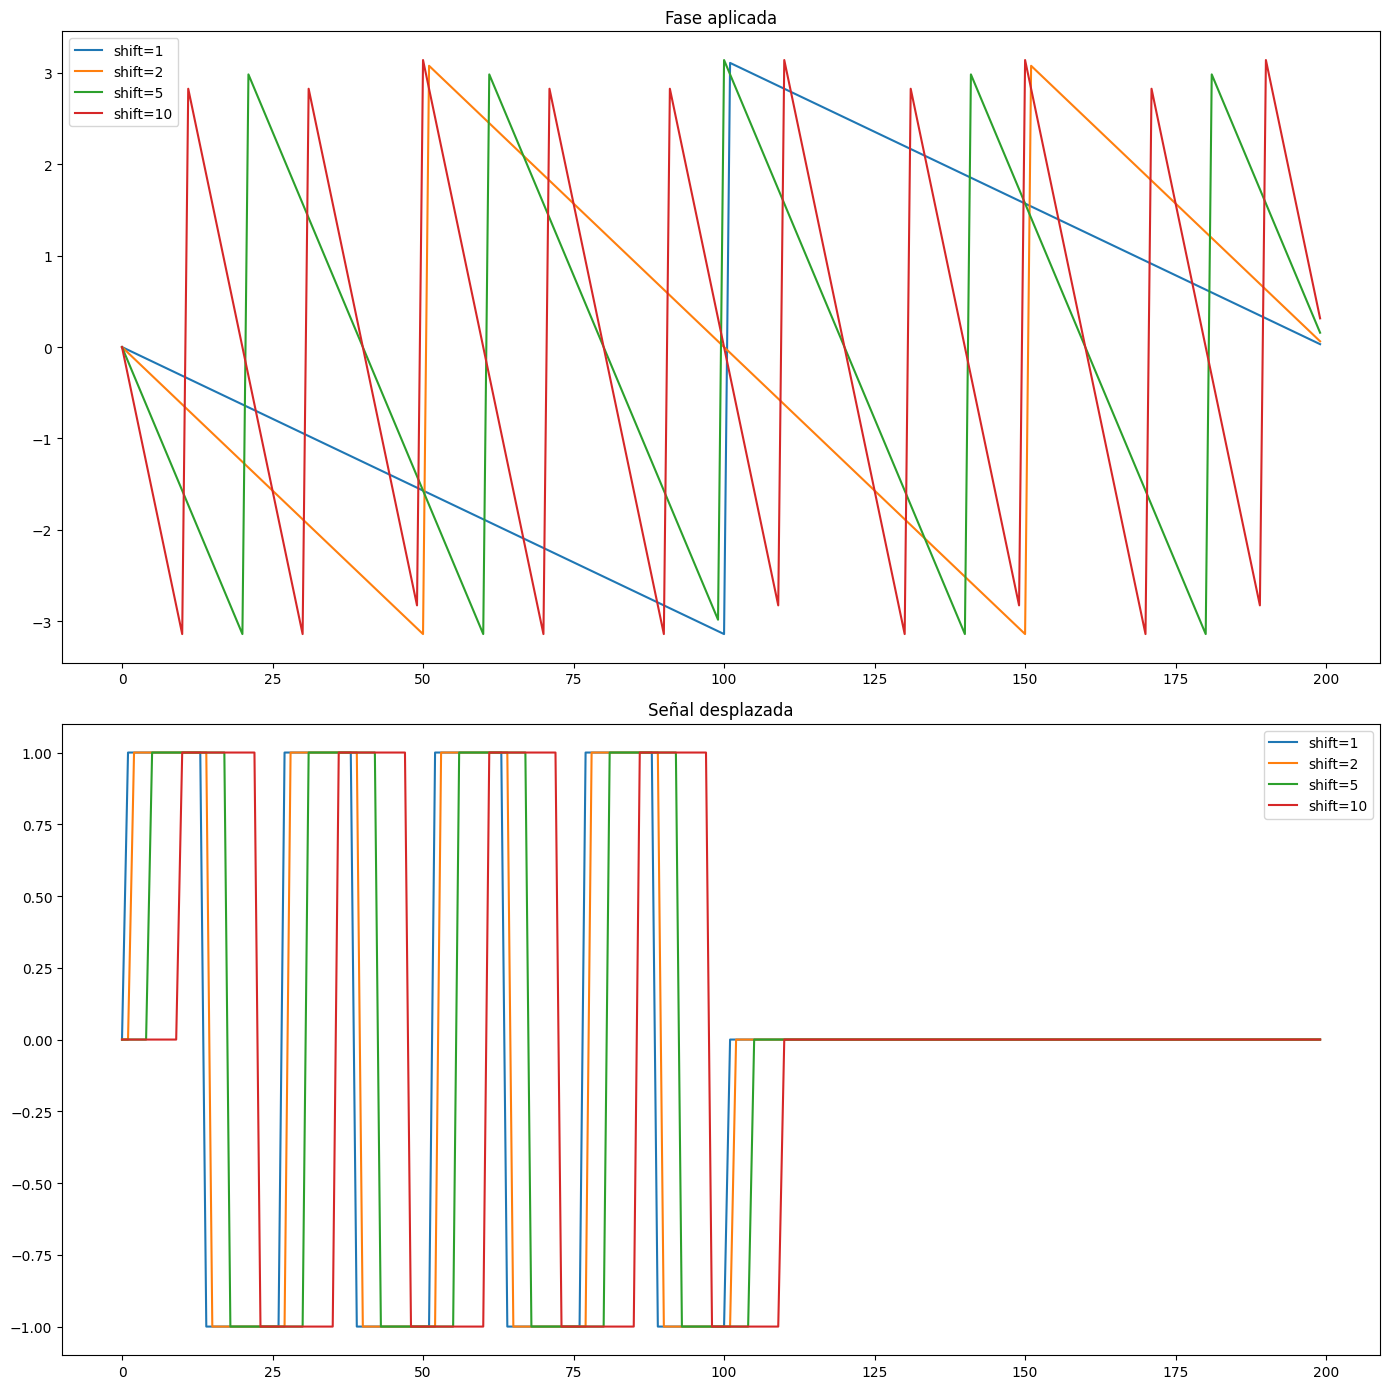

In [44]:
pendientes = [1,2,5,10]
reconstrucciones = []

N = len(seno_comb)

k = np.arange(N)

plt.figure(figsize=(14,14))

for i,pendiente in enumerate(pendientes):

    fase = np.exp(
        -1j * 2*np.pi * k * pendiente / N
    )

    Y = fft_seno_comb * fase

    y = np.real(np.fft.ifft(Y))
    reconstrucciones.append(y)

    plt.subplot(2,1,1)
    plt.title("Fase aplicada")

    plt.plot(
        np.angle(fase),
        label=f"shift={pendiente}"
    )

    plt.legend()
    plt.grid()

    plt.subplot(2,1,2)
    plt.title("Señal desplazada")

    plt.plot(
        y,
        label=f"shift={pendiente}"
    )

    plt.legend()
    plt.grid()

plt.tight_layout()
plt.show()

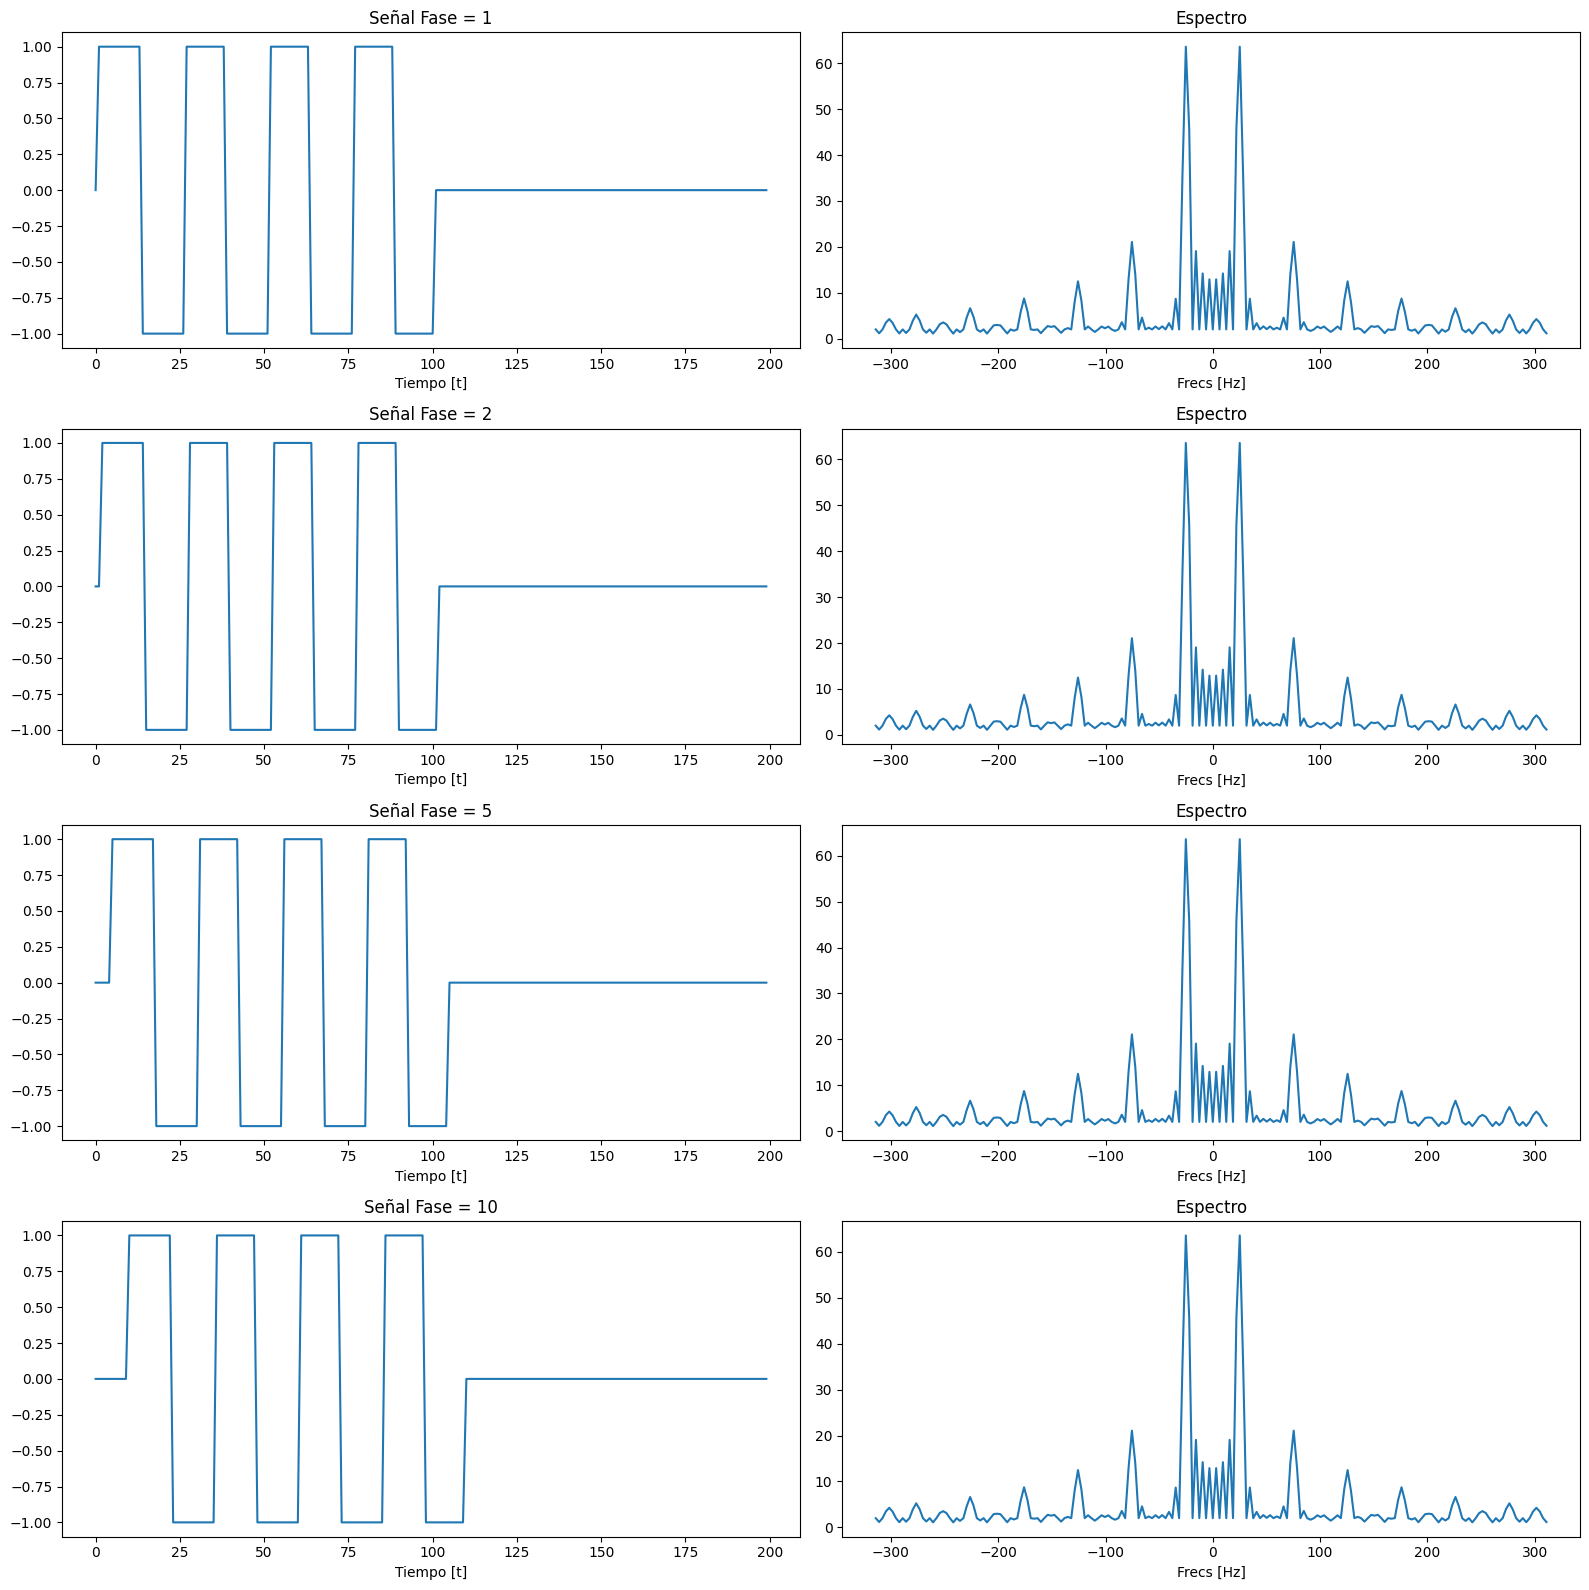

In [ ]:

plt.figure(figsize=(16,16))
for i in range(len(reconstrucciones)):
    y = reconstrucciones[i]

    Y = np.fft.fft(y)
    norm_Y = np.abs(Y)
    shift_Y = np.fft.fftshift(norm_Y)
    plt.subplot(4, 2, 2*i + 1)
    plt.title(f"Señal Fase = {pendientes[i]}")
    plt.plot(y)
    plt.xlabel("Tiempo [t]")

    plt.subplot(4, 2, 2*(i+1))
    plt.title("Espectro")
    plt.plot(shift_frecs, shift_Y)
    plt.xlabel("Frecs [Hz]")
plt.tight_layout()
plt.show()